In [1]:
!pip install gensim
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from gensim.models import FastText
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.6 MB/s eta 0:00:00


In [1]:
import pandas as pd
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of your target labels

# Calculate frequency of 1s for each label
label_counts = train_df[target_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Frequency of Toxicity Labels')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45)
plt.show()

NameError: name 'target_cols' is not defined

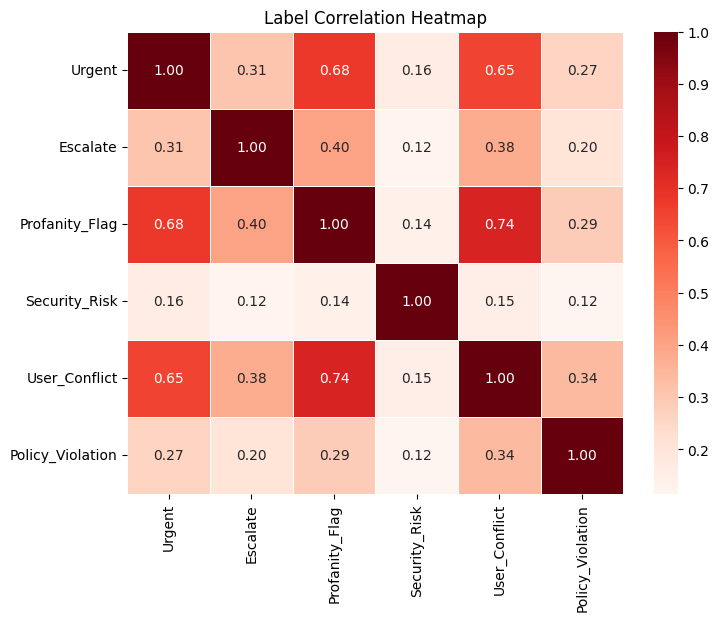

In [ ]:
# Calculate the correlation matrix
corr = train_df[target_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Reds', fmt=".2f", linewidths=.5)
plt.title('Label Correlation Heatmap')
plt.show()

count    159571.000000
mean         67.197022
std          99.148336
min           1.000000
25%          17.000000
50%          36.000000
75%          75.000000
max        1411.000000
Name: comment_text, dtype: float64
<bound method Series.mode of 0          42
1          17
2          41
3         113
4          13
         ... 
159566     47
159567     17
159568     12
159569     25
159570     36
Name: comment_text, Length: 159571, dtype: int64>


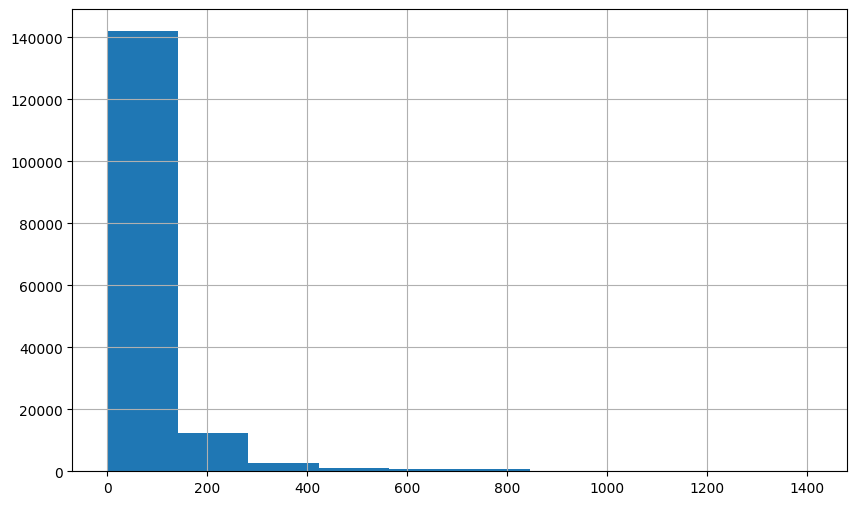

In [ ]:
lengths = train_df['comment_text'].apply(lambda x: len(x.split()))
print(lengths.describe())
print(lengths.mode)
plt.figure(figsize=(10, 6))
lengths.hist()
plt.show()

In [ ]:
limit = df['comment_text'].apply(lambda x: len(x.split())).quantile(0.90)
print(f"90% of comments are shorter than: {limit}")

90% of comments are shorter than: 151.0


In [3]:
import numpy as np
import re
import string
import nltk
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

class AdvancedTextPreprocessor:
    """
    Advanced preprocessing pipeline for toxic comment classification
    Optimized for FastText embeddings
    """

    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        toxic_words = {'no', 'not', 'never', 'none', 'nobody', 'nothing', 'without'}
        self.stop_words = self.stop_words - toxic_words
        self.lemmatizer = WordNetLemmatizer()

        self.contractions = {
            "ain't": "am not", "aren't": "are not", "can't": "cannot", "can't've": "cannot have",
            "'cause": "because", "could've": "could have", "couldn't": "could not", "couldn't've": "could not have",
            "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not",
            "hadn't've": "had not have", "hasn't": "has not", "haven't": "have not", "he'd": "he would",
            "he'd've": "he would have", "he'll": "he will", "he'll've": "he will have", "he's": "he is",
            "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
            "i'd": "i would", "i'd've": "i would have", "i'll": "i will", "i'll've": "i will have",
            "i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would", "it'd've": "it would have",
            "it'll": "it will", "it'll've": "it will have", "it's": "it is", "let's": "let us",
            "ma'am": "madam", "mayn't": "may not", "might've": "might have", "mightn't": "might not",
            "mightn't've": "might not have", "must've": "must have", "mustn't": "must not",
            "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have",
            "o'clock": "of the clock", "oughtn't": "ought not", "oughtn't've": "ought not have",
            "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
            "she'd": "she would", "she'd've": "she would have", "she'll": "she will",
            "she'll've": "she will have", "she's": "she is", "should've": "should have",
            "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have",
            "so's": "so as", "that'd": "that would", "that'd've": "that would have", "that's": "that is",
            "there'd": "there would", "there'd've": "there would have", "there's": "there is",
            "they'd": "they would", "they'd've": "they would have", "they'll": "they will",
            "they'll've": "they will have", "they're": "they are", "they've": "they have",
            "to've": "to have", "wasn't": "was not", "we'd": "we would", "we'd've": "we would have",
            "we'll": "we will", "we'll've": "we will have", "we're": "we are", "we've": "we have",
            "weren't": "were not", "what'll": "what will", "what'll've": "what will have",
            "what're": "what are", "what's": "what is", "what've": "what have", "when's": "when is",
            "when've": "when have", "where'd": "where did", "where's": "where is", "where've": "where have",
            "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
            "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not",
            "won't've": "will not have", "would've": "would have", "wouldn't": "would not",
            "wouldn't've": "would not have", "y'all": "you all", "y'all'd": "you all would",
            "y'all'd've": "you all would have", "y'all're": "you all are", "y'all've": "you all have",
            "you'd": "you would", "you'd've": "you would have", "you'll": "you will",
            "you'll've": "you will have", "you're": "you are", "you've": "you have"
        }

        # Words that indicate negation (important for toxicity)
        self.negation_words = {'no', 'not', 'never', 'none', 'nor', 'neither', 'nobody', 'nothing', 'nowhere'}

        # Toxic keywords that should never be removed
        self.toxic_keywords = {'kill', 'die', 'death', 'hate', 'stupid', 'idiot', 'dumb', 'fool', 'ugly',
                               'fat', 'lazy', 'greedy', 'selfish', 'evil', 'devil', 'hell', 'damn','piss',
                               'cocksucker','f*ck','co**sucker','monkey','fuckin','sex','bullshit','cunt ','[racial_slur]','[ethnic_slur]'
                               'crap', 'suck', 'shit', 'fuck', 'ass', 'bitch', 'bastard', 'dick', 'pussy'}

    def expand_contractions(self, text):
        """Expand contractions for better tokenization"""
        for contraction, expansion in self.contractions.items():
            text = text.replace(contraction, expansion)
        return text

    def clean_text(self, text):
        """Basic text cleaning"""
        if not isinstance(text, str):
            return ""

        text = text.lower()

        text = self.expand_contractions(text)

        text = re.sub(r'<[^>]+>', ' ', text)

        text = re.sub(r'https?://\S+|www\.\S+', ' URL ', text)

        text = re.sub(r'\S+@\S+', ' EMAIL ', text)

        text = re.sub(r'@\w+', ' USER ', text)

        text = re.sub(r'\b\d+\b', ' NUM ', text)

        # Remove punctuation but keep important ones like ! and ? (for profanity)
        punctuation_to_keep = set('!?')
        punctuation_to_remove = set(string.punctuation) - punctuation_to_keep
        text = ''.join(c for c in text if c not in punctuation_to_remove)

        text = re.sub(r'!+', ' ! ', text)
        text = re.sub(r'\?+', ' ? ', text)

        # Handle repeated characters (e.g., "soooo" -> "soo" but preserve meaning) for fasttext
        text = re.sub(r'(.)\1{2,}', r'\1\1', text)

        text = re.sub(r'\s+', ' ', text).strip()

        return text

    def handle_negations(self, tokens):
        """Handle negation words by marking them"""
        processed = []
        negation_scope = False
        negation_window = 3  # Number of words after negation to mark

        for i, token in enumerate(tokens):
            if token in self.negation_words:
                negation_scope = True
                processed.append(f"NOT_{token}")
                continue

            if negation_scope and i > 0 and tokens[i-1] in self.negation_words:
                processed.append(f"NEG_{token}")
                negation_window -= 1
                if negation_window <= 0:
                    negation_scope = False
            else:
                processed.append(token)

        return processed

    def process(self, text, remove_stopwords=True, lemmatize=True, handle_negations=True):
        """Main preprocessing function"""
        text = self.clean_text(text)

        tokens = word_tokenize(text)

        if handle_negations:
            tokens = self.handle_negations(tokens)

        if remove_stopwords:
            tokens = [t for t in tokens if t not in self.stop_words or
                     t in self.negation_words or t in self.toxic_keywords]

        if lemmatize: #fasttext doesn't need lemmatize
            tokens = [self.lemmatizer.lemmatize(t) for t in tokens]

        return ' '.join(tokens)


In [4]:
class VocabularyBuilder:
    """Build vocabulary optimized for FastText embeddings"""

    def __init__(self, min_freq=2, max_size=100000):
        self.min_freq = min_freq
        self.max_size = max_size
        self.word_counts = Counter()
        self.vocab = {}

        # Special tokens
        self.special_tokens = ['<PAD>', '<UNK>', '<START>', '<END>']

    def build(self, texts):
        """Build vocabulary from texts"""
        # Count word frequencies
        for text in texts:
            words = text.split()
            self.word_counts.update(words)

        words = [(word, count) for word, count in self.word_counts.items()
                 if count >= self.min_freq]
        words.sort(key=lambda x: (-x[1], x[0]))

        # Limit vocabulary size
        if len(words) > self.max_size:
            words = words[:self.max_size]

        # Build vocabulary mapping
        for i, token in enumerate(self.special_tokens):
            self.vocab[token] = i

        for i, (word, _) in enumerate(words):
            self.vocab[word] = i + len(self.special_tokens)

        return self.vocab

    def text_to_sequence(self, text, max_len=200):
        """Convert text to sequence of indices"""
        words = text.split()

        # Truncate if too long
        if len(words) > max_len - 2:  # Leave room for START and END tokens
            words = words[:max_len - 2]

        # Convert to indices with START and END tokens
        seq = [self.vocab.get('<START>', 1)]
        seq.extend([self.vocab.get(word, self.vocab.get('<UNK>', 1)) for word in words])
        seq.append(self.vocab.get('<END>', 1))

        # Pad if too short
        if len(seq) < max_len:
            seq.extend([self.vocab.get('<PAD>', 0)] * (max_len - len(seq)))

        return torch.tensor(seq, dtype=torch.long)


In [5]:

class FastTextEmbeddingLoader:
    """
    Load FastText embeddings with subword information handling
    """

    def __init__(self, filepath='crawl-300d-2M.vec', embedding_dim=300):
        self.filepath = filepath
        self.embedding_dim = embedding_dim
        self.embeddings_index = {}

    def load_embeddings(self):
        """Load FastText embeddings"""
        print(f"Loading FastText embeddings from {self.filepath}...")

        with open(self.filepath, 'r', encoding='utf-8', errors='ignore') as f:
            # First line contains vocab size and dimension
            first_line = f.readline().strip()
            vocab_size, dim = map(int, first_line.split())

            # Load embeddings
            for line in f:
                values = line.rstrip().split(' ')
                word = values[0]
                vector = np.asarray(values[1:], dtype='float32')
                self.embeddings_index[word] = vector

        print(f"Loaded {len(self.embeddings_index)} word vectors")
        return self.embeddings_index

    def create_embedding_matrix(self, vocab, oov_strategy='subword'):
        """
        Create embedding matrix with OOV handling strategies:
        - 'random': random initialization
        - 'subword': average of subword n-grams (requires FastText binary)
        - 'zeros': zero initialization
        """
        vocab_size = len(vocab)
        embedding_matrix = np.zeros((vocab_size, self.embedding_dim))

        # Count how many words we found
        found = 0

        for word, idx in vocab.items():
            if word in self.embeddings_index:
                embedding_matrix[idx] = self.embeddings_index[word]
                found += 1
            elif word.lower() in self.embeddings_index:
                embedding_matrix[idx] = self.embeddings_index[word.lower()]
                found += 1
            else:
                # OOV strategy: random small noise
                embedding_matrix[idx] = np.random.normal(0, 0.1, self.embedding_dim)

        print(f"Found {found}/{vocab_size} words in FastText embeddings")

        # Special token embeddings (initialize with zeros)
        for i, token in enumerate(['<PAD>', '<UNK>', '<START>', '<END>']):
            if token in vocab:
                embedding_matrix[vocab[token]] = np.zeros(self.embedding_dim)

        return embedding_matrix

In [6]:
class Dataset(Dataset):
    """PyTorch Dataset for toxic comment classification"""

    def __init__(self, df, vocab_builder, target_cols, is_test=False):
        self.df = df  # Store the dataframe for CV and weight calculation
        self.sequences = [vocab_builder.text_to_sequence(text) for text in df['processed_text']]
        self.is_test = is_test

        if not is_test:
            self.labels = torch.tensor(df[target_cols].values, dtype=torch.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        if self.is_test:
            return self.sequences[idx]
        return self.sequences[idx], self.labels[idx]

In [7]:
import os

# Download FastText embeddings (Common Crawl - 300d - 2M vectors)
if not os.path.exists('crawl-300d-2M.vec'):
    print("Downloading FastText embeddings...")
    !wget https://dl.fbaipublicfiles.com/fasttext/vectors-english/crawl-300d-2M.vec.zip
    print("Unzipping file...")
    !unzip crawl-300d-2M.vec.zip
    # Clean up zip file
    !rm crawl-300d-2M.vec.zip
    print("Done!")
else:
    print("Embeddings already exist.")

--2026-04-18 13:13:22--  https://dl.fbaipublicfiles.com/fasttext/vectors-english/crawl-300d-2M.vec.zip
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.13, 3.171.22.33, 3.171.22.68, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1523785255 (1.4G) [application/zip]
Saving to: ‘crawl-300d-2M.vec.zip’

crawl-300d-2M.vec.z 100%[===================>]   1.42G   100MB/s    in 10s     

2026-04-18 13:13:33 (143 MB/s) - ‘crawl-300d-2M.vec.zip’ saved [1523785255/1523785255]

Unzipping file...
Archive:  crawl-300d-2M.vec.zip
  inflating: crawl-300d-2M.vec       
Done!


In [8]:

def preprocess_data(train_df, test_df, target_cols):
    """
    Complete preprocessing pipeline
    """
    print("=" * 50)
    print("Starting preprocessing pipeline...")
    print("=" * 50)

    # Initialize preprocessor
    preprocessor = AdvancedTextPreprocessor()

    # Process training data
    print("\nProcessing training data...")
    train_df['processed_text'] = train_df['comment_text'].apply(
        lambda x: preprocessor.process(x, remove_stopwords=True, lemmatize=False, handle_negations=True)
    )

    # Process test data
    print("Processing test data...")
    test_df['processed_text'] = test_df['comment_text'].apply(
        lambda x: preprocessor.process(x, remove_stopwords=True, lemmatize=False, handle_negations=True)
    )

    print("\nBuilding vocabulary...")
    vocab_builder = VocabularyBuilder(min_freq=3, max_size=50000)
    all_texts = pd.concat([train_df['processed_text'], test_df['processed_text']])
    vocab = vocab_builder.build(all_texts)
    print(f"Vocabulary size: {len(vocab)}")

    print("\nLoading FastText embeddings...")
    ft_loader = FastTextEmbeddingLoader(filepath='crawl-300d-2M.vec', embedding_dim=300)
    ft_loader.load_embeddings()
    embedding_matrix = ft_loader.create_embedding_matrix(vocab)

    print("\nCreating datasets...")
    train_dataset = Dataset(train_df, vocab_builder, target_cols, is_test=False)
    test_dataset = Dataset(test_df, vocab_builder, target_cols, is_test=True)

    return train_dataset, test_dataset, vocab_builder, embedding_matrix


In [9]:
target_cols = ['Urgent', 'Escalate', 'Profanity_Flag', 'Security_Risk', 'User_Conflict', 'Policy_Violation']

train_dataset, test_dataset, vocab_builder, embedding_matrix = preprocess_data(train_df, test_df, target_cols)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Starting preprocessing pipeline...

Processing training data...
Processing test data...

Building vocabulary...
Vocabulary size: 50004

Loading FastText embeddings...
Loading FastText embeddings from crawl-300d-2M.vec...
Loaded 1999995 word vectors
Found 40776/50004 words in FastText embeddings

Creating datasets...


In [3]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [4]:

class AttentionLayer(nn.Module):
    """
    Self-attention mechanism for Bi-LSTM outputs
    Helps model focus on important words by learning importance of each token dynamically
    """
    def __init__(self, hidden_size, bidirectional=True):
        super(AttentionLayer, self).__init__()
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Attention parameters
        self.W = nn.Linear(hidden_size * (2 if bidirectional else 1), hidden_size)
        self.V = nn.Linear(hidden_size, 1)

    def forward(self, lstm_output):
        # lstm_output: [batch_size, seq_len, hidden_size * (2 if bidirectional else 1)]

        attention_weights = torch.tanh(self.W(lstm_output))
        attention_weights = self.V(attention_weights).squeeze(-1)
        attention_weights = F.softmax(attention_weights, dim=1)

        # Apply attention
        attended_output = torch.bmm(attention_weights.unsqueeze(1), lstm_output).squeeze(1)

        return attended_output, attention_weights


In [5]:

class BiLstm(nn.Module):
    """
    Bidirectional LSTM with Attention pooling
    """
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes,
                 pretrained_embeddings=None, use_attention=True):
        super(BiLstm, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.use_attention = use_attention

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.embedding.weight = nn.Parameter(torch.tensor(pretrained_embeddings, dtype=torch.float32))
        self.embedding.weight.requires_grad = True

        self.embedding_dropout = nn.Dropout(0.25)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # Attn pooling
        if use_attention:
            self.attention = AttentionLayer(hidden_size, bidirectional=True)

        self.batch_norm = nn.BatchNorm1d(hidden_size * 2)

        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.5 * 0.8)

        self.fc1 = nn.Linear(hidden_size * 2, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, num_classes)

        self.relu = nn.ReLU()

        self._init_weights()

    def _init_weights(self):
        """keep embeddings uniformly init, use xavier for weights"""
        for name, param in self.named_parameters():
            if 'weight' in name and 'embedding' not in name:
                if len(param.shape) >= 2:
                    nn.init.xavier_uniform_(param)
                else:
                    nn.init.uniform_(param, -0.1, 0.1)
            elif 'bias' in name:
                nn.init.constant_(param, 0)

    def forward(self, x, lengths=None):
        # x: [batch_size, seq_len]

        embedded = self.embedding(x)
        embedded = self.embedding_dropout(embedded)

        # Pack sequence if lengths provided (for variable length sequences)
        if lengths is not None:
            embedded = nn.utils.rnn.pack_padded_sequence(embedded, lengths,
                                                        batch_first=True, enforce_sorted=False)

        lstm_output, (hidden, cell) = self.lstm(embedded)

        # Unpack if packed
        if lengths is not None:
            lstm_output, _ = nn.utils.rnn.pad_packed_sequence(lstm_output, batch_first=True)


        if self.use_attention:
            pooled, attention_weights = self.attention(lstm_output)
        else:
            # pooled, _ = torch.max(lstm_output, dim=1)
            pooled = torch.mean(lstm_output, dim=1)

        # Batch normalization
        pooled = self.batch_norm(pooled)

        # Dense layer
        x = self.dropout1(pooled)
        x = self.fc1(x)
        x = self.relu(x)


        x = self.dropout2(x)
        x = self.fc2(x)
        x = self.relu(x)

        x = self.dropout1(x)
        x = self.fc3(x)

        return x


In [6]:

def train_epoch(model, dataloader, optimizer, criterion, device):
    """Train one epoch"""
    model.train()
    total_loss = 0
    predictions = []
    labels_list = []

    for batch_idx, (data, targets) in enumerate(dataloader):
        data, targets = data.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)

        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

        predictions.append(torch.sigmoid(outputs).detach().cpu().numpy())
        labels_list.append(targets.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    predictions = np.vstack(predictions)
    labels = np.vstack(labels_list)

    return avg_loss, predictions, labels


def evaluate(model, dataloader, criterion, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    predictions = []
    labels_list = []

    with torch.no_grad():
        for data, targets in dataloader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            loss = criterion(outputs, targets)

            total_loss += loss.item()
            predictions.append(torch.sigmoid(outputs).cpu().numpy())
            labels_list.append(targets.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    predictions = np.vstack(predictions)
    labels = np.vstack(labels_list)

    return avg_loss, predictions, labels


In [7]:

def calculate_roc_auc(y_true, y_pred, target_cols):
    """Calculate mean column-wise ROC AUC"""
    auc_scores = []
    for i, col in enumerate(target_cols):
        try:
            auc = roc_auc_score(y_true[:, i], y_pred[:, i])
            auc_scores.append(auc)
        except:
            auc_scores.append(0.5)  # Fallback for constant predictions

    mean_auc = np.mean(auc_scores)
    return mean_auc, auc_scores


In [8]:
def train_with_cv(train_dataset, target_cols, vocab_size, embedding_matrix,
                  embedding_dim=300, num_folds=5, epochs=5, batch_size=64,
                  learning_rate=1e-3):

    train_df = train_dataset.df.copy() if hasattr(train_dataset, 'df') else None

    # Create stratification labels
    if train_df is not None:
        train_df['stratify_col'] = train_df[target_cols].astype(str).apply(lambda x: ''.join(x), axis=1)
        skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    else:
        # Fallback to random splits
        skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
        # Create dummy labels if needed
        train_df = pd.DataFrame({'stratify_col': [0] * len(train_dataset)})

    fold_scores = []
    fold_predictions = []
    models = []

    print(f"\n{'='*60}")
    print(f"Starting {num_folds}-Fold Cross Validation")
    print(f"{'='*60}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['stratify_col'])):
        print(f"\n--- Fold {fold + 1}/{num_folds} ---")

        if hasattr(train_dataset, 'df'):
            train_subset = torch.utils.data.Subset(train_dataset, train_idx)
            val_subset = torch.utils.data.Subset(train_dataset, val_idx)
        else:
            train_subset = torch.utils.data.Subset(train_dataset, train_idx)
            val_subset = torch.utils.data.Subset(train_dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
        model = BiLstm(
            vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_size=256, num_layers=2, num_classes=len(target_cols),
            pretrained_embeddings=embedding_matrix, use_attention=True
            ).to(device)

        # Calculate class weights for imbalance among multi-label classification
        if train_df is not None:
            pos_counts = train_df.iloc[train_idx][target_cols].sum()
            neg_counts = len(train_idx) - pos_counts
            pos_weights = neg_counts / (pos_counts + 1e-8)
            pos_weights = np.clip(pos_weights, 1.0, 10.0)  # gradient exploding
        else:
            pos_weights = np.ones(len(target_cols))

        # criterion = WeightedBCELoss(pos_weights=pos_weights)
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weights, dtype=torch.float32).to(device))

        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)

        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=2, T_mult=2)


        best_auc = 0
        best_model_state = None
        patience = 2 # for early dropping
        patience_counter = 0

        for epoch in range(epochs):
            # Train
            train_loss, train_preds, train_labels = train_epoch(model, train_loader, optimizer, criterion, device)
            train_auc, _ = calculate_roc_auc(train_labels, train_preds, target_cols)

            # Validate
            val_loss, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
            val_auc, val_auc_scores = calculate_roc_auc(val_labels, val_preds, target_cols)


            scheduler.step()

            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}")

            # Save best model
            if val_auc > best_auc:
                best_auc = val_auc
                best_model_state = model.state_dict().copy()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        # Load best model for this fold
        model.load_state_dict(best_model_state)
        models.append(model)

        # Final evaluation on validation set
        _, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
        val_auc, val_auc_scores = calculate_roc_auc(val_labels, val_preds, target_cols)

        fold_scores.append(val_auc)
        fold_predictions.append(val_preds)

        print(f"Fold {fold + 1} Best Validation AUC: {val_auc:.4f}")
        print(f"Per-class AUC: {[f'{score:.4f}' for score in val_auc_scores]}")

    # Overall CV score
    cv_score = np.mean(fold_scores)
    print(f"\n{'='*60}")
    print(f"Cross-Validation Mean ROC AUC: {cv_score:.4f} (+/- {np.std(fold_scores):.4f})")
    print(f"{'='*60}")

    return models, cv_score, fold_predictions


In [9]:

def ensemble_predictions(models, test_dataset, batch_size=64, device='cuda'):
    """
    Ensemble predictions from multiple models
    """
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    all_predictions = []

    for model in models:
        model.eval()
        fold_preds = []

        with torch.no_grad():
            for data in test_loader:
                data = data.to(device)
                outputs = model(data)
                probs = torch.sigmoid(outputs)
                fold_preds.append(probs.cpu().numpy())

        fold_preds = np.vstack(fold_preds)
        all_predictions.append(fold_preds)

    # Average predictions across folds
    ensemble_preds = np.mean(all_predictions, axis=0)

    return ensemble_preds


In [10]:

def train_model(train_dataset, test_dataset, vocab_size, embedding_matrix, target_cols):
    """
    Main function to train the winning model
    """

    models, cv_score, fold_predictions = train_with_cv(
        train_dataset=train_dataset,
        target_cols=target_cols,
        vocab_size=vocab_size,
        embedding_matrix=embedding_matrix,
        embedding_dim=300,
        num_folds=5,
        epochs=6,
        batch_size=64,
        learning_rate=1e-4,
    )
    print("\nGenerating test predictions...")
    test_predictions = ensemble_predictions(models, test_dataset, batch_size=64, device=device)

    return test_predictions, cv_score


In [11]:
def create_submission(test_predictions, target_cols, filename='submission.csv'):
    """
    Create submission file
    """
    submission = pd.DataFrame(test_predictions, columns=target_cols)
    submission.insert(0, 'id', test_df['id'].values)
    submission.to_csv(filename, index=False)
    print(f"\nSubmission saved to {filename}")
    return submission


In [ ]:
# Train the winning model
test_predictions, cv_score = train_model(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    vocab_size=len(vocab_builder.vocab),
    embedding_matrix=embedding_matrix,
    target_cols=target_cols,
)

In [ ]:
# Create submission
create_submission(test_predictions, target_cols, 'submission.csv')